# KPI 1 y KPI 2 — Servicio Ciudadano 1800
Carga los datasets desde SQL Server (Docker) y muestra los 2 indicadores aprobados: Tasa de Recontacto en 7 Días (TR7D) y Duración Promedio de Interacción (DPI), desagregados por sus dimensiones.

In [6]:
import sys
sys.path.insert(0, '../src')

import matplotlib.pyplot as plt
from cargar_datos import cargar_kpi_recontacto, cargar_kpi_duracion

df_recontacto = cargar_kpi_recontacto()
df_duracion = cargar_kpi_duracion()

📊 CARGANDO DATASET — KPI 1: Tasa de Recontacto en 7 Días


/home/abemilek/Documentos/workspace/servicio-ciudadano-mineria/proyecto/notebooks/../src/database.py:67: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql_query(query, conn, params=params) if params else pd.read_sql_query(query, conn)



📏 Dimensiones: 9,830 filas × 10 columnas

🎯 TR7D global: 40.36%

📈 TR7D por canal:
canal
(sin dato)    38.00
Chat          40.14
Correo        39.36
Red social    46.11
Teléfono      38.00
Name: recontacto_7_dias, dtype: float64

📈 TR7D por motivo:
motivo_contacto
Cobro        37.61
Consulta     30.97
Falla        49.67
Queja        43.34
Solicitud    40.22
Name: recontacto_7_dias, dtype: float64

📈 TR7D por cola de servicio:
cola_servicio
Facturación    47.86
Información    41.95
Reclamos       35.89
Soporte        35.45
Trámites       40.85
Name: recontacto_7_dias, dtype: float64

📊 CARGANDO DATASET — KPI 2: Duración Promedio de Interacción


/home/abemilek/Documentos/workspace/servicio-ciudadano-mineria/proyecto/notebooks/../src/database.py:67: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql_query(query, conn, params=params) if params else pd.read_sql_query(query, conn)



📏 Dimensiones: 10,000 filas × 9 columnas

🎯 DPI global: 944.6 seg (15.7 min)

📈 DPI por canal:
canal
(sin dato)     959.0
Chat          1026.4
Correo         920.3
Red social     853.4
Teléfono       949.6
Name: duracion_seg, dtype: float64


## KPI 1 — Tasa de Recontacto en 7 Días (TR7D)

TR7D global: 40.36%


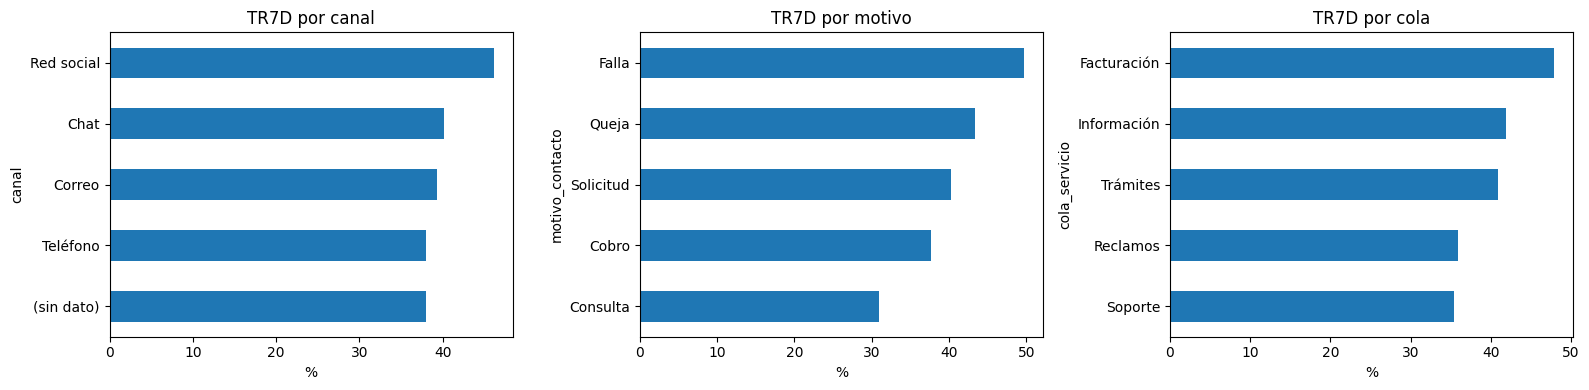

In [7]:
tr7d_global = df_recontacto['recontacto_7_dias'].mean() * 100
print(f"TR7D global: {tr7d_global:.2f}%")

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

(df_recontacto.groupby('canal')['recontacto_7_dias'].mean() * 100).sort_values().plot(
    kind='barh', ax=axes[0], title='TR7D por canal')
(df_recontacto.groupby('motivo_contacto')['recontacto_7_dias'].mean() * 100).sort_values().plot(
    kind='barh', ax=axes[1], title='TR7D por motivo')
(df_recontacto.groupby('cola_servicio')['recontacto_7_dias'].mean() * 100).sort_values().plot(
    kind='barh', ax=axes[2], title='TR7D por cola')

for ax in axes:
    ax.set_xlabel('%')
plt.tight_layout()
plt.show()

## KPI 1 — Tendencia mensual

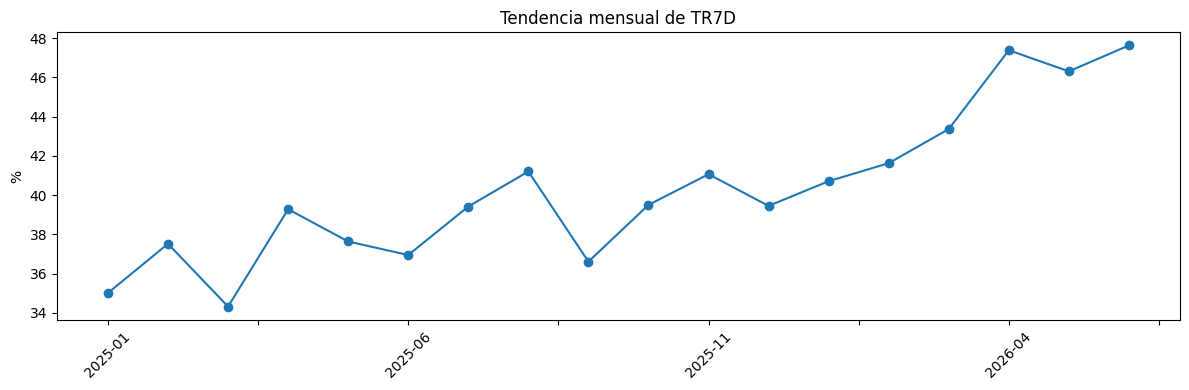

In [8]:
tendencia = (df_recontacto.groupby(['anio', 'mes'])['recontacto_7_dias'].mean() * 100)
tendencia.index = [f"{a}-{m:02d}" for a, m in tendencia.index]
tendencia.plot(figsize=(12, 4), marker='o', title='Tendencia mensual de TR7D')
plt.ylabel('%')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## KPI 2 — Duración Promedio de Interacción (DPI)

DPI global: 944.6 seg (15.7 min)


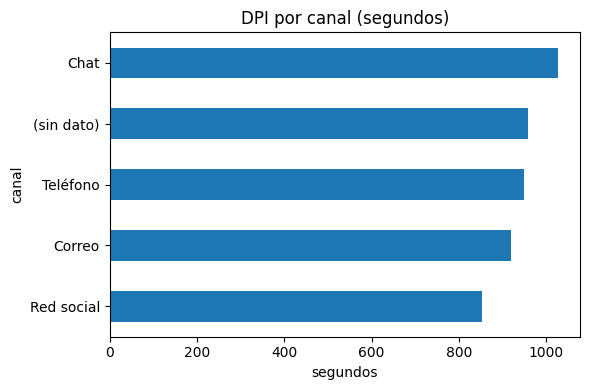

In [9]:
dpi_global = df_duracion['duracion_seg'].mean()
print(f"DPI global: {dpi_global:.1f} seg ({dpi_global/60:.1f} min)")

df_duracion.groupby('canal')['duracion_seg'].mean().sort_values().plot(
    kind='barh', figsize=(6, 4), title='DPI por canal (segundos)')
plt.xlabel('segundos')
plt.tight_layout()
plt.show()

## Cruce KPI1 x KPI2 (hipótesis a validar con minería, no es un hallazgo confirmado)

In [10]:
resumen = df_recontacto.groupby('canal')['recontacto_7_dias'].mean().mul(100).rename('TR7D_%')
resumen = resumen.to_frame().join(df_duracion.groupby('canal')['duracion_seg'].mean().rename('DPI_seg'))
resumen

,TR7D_%,DPI_seg
canal,,
(sin dato),38.000000,958.996000
Chat,40.139401,1026.355332
Correo,39.356179,920.328718
Red social,46.109052,853.419171
Teléfono,38.003608,949.619498
